# Analisis Eksploratif Potensi Desa di Indonesia

## Tujuan

Tujuan dari analisis ini adalah mendapatkan insight terkait potensi desa di Indonesia dalam berbagai bidang, seperti kependudukan, fasilitas, ekonomi, dan infrastruktur.

Sumber yang digunakan yaitu data Badan Pusat Statistik (BPS) dan Portal Data Kementerian Desa (Kemendesa)

In [1]:
# Import Libraries
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## 3. Visualisasi Peta

Visualisasi berupa peta sebaran potensi desa menggunakan tools visualisasi, yaitu Python dan Tableau Public

In [2]:
# Membuat daftar file csv yang telah diunduh
script_dir = os.getcwd()
csv_files = glob.glob(os.path.join(script_dir, 'data/processed', '*.csv'))
print(len(csv_files))

26


In [3]:
# Membuka file dan menyimpannya dalam dataframe
dataframes = {}

for file_path in csv_files:
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    df = pd.read_csv(file_path, encoding='latin1')
    dataframes[file_name] = df

In [4]:
# Menyamakan nama provinsi antar data desa
peta_provinsi_desa = {
    'Jakarta/Pusat': 'DKI Jakarta',
    'Dki Jakarta': 'DKI Jakarta',
    'DI Yogyakarta': 'Daerah Istimewa Yogyakarta',
    'Di Yogyakarta': 'Daerah Istimewa Yogyakarta'
}

### Peta Persebaran Menara BTS di Desa per Provinsi Tahun 2021

In [5]:
df_07 = dataframes['07_Banyaknya Desa_Kelurahan yang Memiliki Menara Base Transceiver Station (BTS) menurut Provinsi dan Klasifikasi Daerah, 2021-processed'][:-1].copy()
df_07['Provinsi'] = df_07['Provinsi'].str.title().replace(peta_provinsi_desa)

In [6]:
# Export file to excel for Tableau
file_excel_07 = '07_Banyaknya Desa_Kelurahan yang Memiliki Menara Base Transceiver Station (BTS) menurut Provinsi dan Klasifikasi Daerah, 2021-processed.xlsx'
df_07.to_excel(file_excel_07, index=False)

![Menara BTS Desa 2021](<images/Peta Jumlah Menara BTS Desa 2021.png>)

### Peta Persebaran Jumlah Desa

In [7]:
# Peta Persebaran Jumlah Desa
# Tidak memasukkan 3 baris terakhir yang merupakan total Indonesia dan keterangan
df_12 = dataframes['12_Jumlah Desa_Kelurahan Menurut Provinsi, 2024-processed'][:-3].copy()
df_12['Provinsi'] = df_12['Provinsi'].replace(peta_provinsi_desa)

# Provinsi di Indonesia terdiri atas 38 Provinsi
print(f"{df_12['Provinsi'].count()} Provinsi di Indonesia: ", df_12['Provinsi'].tolist())

38 Provinsi di Indonesia:  ['Aceh', 'Sumatera Utara', 'Sumatera Barat', 'Riau', 'Jambi', 'Sumatera Selatan', 'Bengkulu', 'Lampung', 'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'DKI Jakarta', 'Jawa Barat', 'Jawa Tengah', 'Daerah Istimewa Yogyakarta', 'Jawa Timur', 'Banten', 'Bali', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Kalimantan Barat', 'Kalimantan Tengah', 'Kalimantan Selatan', 'Kalimantan Timur', 'Kalimantan Utara', 'Sulawesi Utara', 'Sulawesi Tengah', 'Sulawesi Selatan', 'Sulawesi Tenggara', 'Gorontalo', 'Sulawesi Barat', 'Maluku', 'Maluku Utara', 'Papua Barat', 'Papua Barat Daya', 'Papua', 'Papua Selatan', 'Papua Tengah', 'Papua Pegunungan']


In [8]:
# Export file to excel for Tableau
file_excel_12 = '12_Jumlah Desa_Kelurahan Menurut Provinsi, 2024-processed.xlsx'
df_12.to_excel(file_excel_12, index=False)

![Peta Jumlah Desa per Provinsi 2024](<images/Peta Jumlah Desa 2024.png>)

In [9]:
# Peta Persebaran Status Desa
df_22 = dataframes['22_Jumlah Desa Status Kemajuan-processed'][:-1].copy()
df_22.rename(columns=({'NAMA PROVINSI': 'Provinsi', 'NAMA KABUPATEN': 'Kabupaten'}), inplace=True)
df_22['Provinsi'] = df_22['Provinsi'].astype(str).str.title().replace(peta_provinsi_desa)
df_22['Kabupaten'] = df_22['Kabupaten'].astype(str).str.title()
# Ubah tipe data untuk kolom khusus
df_22.rename(columns=({'TIDAK MEMENUHI KRITERIA (tidak melakukan pengukuran berdasarkan': 'BELUM DIUKUR'}), inplace=True)
df_22.columns = df_22.columns.str.title()
kolom_22_str = ['Kode Provinsi', 'Kode Kab']
kolom_22_int = ['Desa Mandiri', 'Desa Maju', 'Desa Berkembang', 'Desa Tertinggal', 'Desa Sangat Tertinggal', 'Belum Diukur', 'Total Desa']
for col in df_22.columns:
    if col in kolom_22_str:
        df_22[col] = df_22[col].astype(int).astype(str)
    elif col in kolom_22_int:
        df_22[col] = df_22[col].astype(int)

In [10]:
df_22.head()

,Id,Kode Provinsi,Provinsi,Kode Kab,Kabupaten,Desa Mandiri,Desa Maju,Desa Berkembang,Desa Tertinggal,Desa Sangat Tertinggal,Belum Diukur,Total Desa
0,1,11,Aceh,1105,Aceh Barat,21,57,188,54,1,1,322
1,2,11,Aceh,1112,Aceh Barat Daya,7,30,112,3,0,0,152
2,3,11,Aceh,1106,Aceh Besar,45,191,355,12,0,1,604
3,4,11,Aceh,1114,Aceh Jaya,12,28,115,15,2,0,172
4,5,11,Aceh,1101,Aceh Selatan,13,37,159,49,2,0,260


In [11]:
# Export file to excel for Tableau
file_excel_22 = '22_Jumlah Desa Status Kemajuan-processed.xlsx'
df_22.to_excel(file_excel_22, index=False)

![Desa Mandiri 2024](<images/Peta Jumlah Desa Mandiri 2024.png>)

### Peta Persebaran Pelatihan Masyarakat Desa Tahun 2024

In [12]:
df_14 = dataframes['14_data-jumlah-masyarakat-desa-yang-diberikan-pelatihan-tahun-2024-processed'].copy()
df_14.columns = df_14.columns.str.strip().str.title() # Menyamakan format nama kolom
df_14['Provinsi'] = df_14['Provinsi'].str.title().replace(peta_provinsi_desa)
df_14.drop(columns=['No'], inplace=True) # Hapus kolom yang tidak perlu
# Ubah tipe data untuk kolom khusus
kolom_14_str = ['Id_Provinsi', 'Id_Kabupaten', 'Id_Kecamatan', 'Id_Desa']
kolom_14_title = ['Kabupaten', 'Kecamatan', 'Desa']
for col in df_14.columns:
    if col in kolom_14_str:
        df_14[col] = df_14[col].astype(int).astype(str)
    elif col in kolom_14_title:
        df_14[col] = df_14[col].str.title()
df_14['Jenis_Pelatihan'] = df_14['Jenis_Pelatihan'].replace('Bum Desa', 'BUM Desa')
df_14.head()

,Nama_Balai,Jenis_Pelatihan,Waktu_Pelaksanaan,Id_Provinsi,Provinsi,Id_Kabupaten,Kabupaten,Id_Kecamatan,Kecamatan,Id_Desa,Desa,Jumlah
0,Jakarta,BUM Desa,31 Januari - 3 Februari 2024,32,Jawa Barat,3216,Bekasi,321620,Cikarang Pusat,3216202004,Hegarmukti,2
1,Jakarta,BUM Desa,31 Januari - 3 Februari 2024,32,Jawa Barat,3216,Bekasi,321602,Babelan,3216022004,Hurip Jaya,2
2,Jakarta,BUM Desa,31 Januari - 3 Februari 2024,32,Jawa Barat,3216,Bekasi,321621,Serang Baru,3212022007,Jayamulya,2
3,Jakarta,BUM Desa,31 Januari - 3 Februari 2024,32,Jawa Barat,3216,Bekasi,321611,Cikarang Timur,1810052008,Karangsari,2
4,Jakarta,BUM Desa,31 Januari - 3 Februari 2024,32,Jawa Barat,3216,Bekasi,321618,Setu,3206192010,Kertarahayu,2


In [13]:
# Export file to excel for Tableau
file_excel = '14_data-jumlah-masyarakat-desa-yang-diberikan-pelatihan-tahun-2024-processed.xlsx'
df_14.to_excel(file_excel, index=False)

![Pelatihan Desa 2024](<images/Peta Jumlah Pelatihan 2024.png>)

### Peta Persebaran BUMDes

In [14]:
df_17 = dataframes['17_bumdesa-kategori-usaha-processed'].copy()
df_17['Provinsi'] = df_17['Provinsi'].str.title().replace(peta_provinsi_desa)
# Menjaga konsistensi penulisan
df_17['Kabupaten'] = df_17['Kabupaten'].str.title()
df_17['Kecamatan'] = df_17['Kecamatan'].str.title()
df_17['Desa'] = df_17['Desa'].str.title()
df_17.head()

,Provinsi,Kabupaten,Kecamatan,Desa,Nama_BUMDes,ket_kbli,Tipe_BUMDes
0,Aceh,Aceh Selatan,Kluet Utara,Kampung Paya,BUM Desa MUTIARA JAYA KAMPUNG PAYA,PENAMPUNGAN DAN PENYALURAN AIR BAKU 244,BUM Desa
1,Aceh,Aceh Selatan,Kluet Utara,Kampung Paya,BUM Desa MUTIARA JAYA KAMPUNG PAYA,AKTIVITAS PENYEWAAN DAN SEWA GUNA USAHA TANPA ...,BUM Desa
2,Aceh,Aceh Selatan,Kluet Utara,Pasi Kuala Ba'U,BUM Desa MADAT LAMKUTA PASI KUALA BA'U,"PERDAGANGAN ECERAN KOPI, GULA PASIR DAN GULA M...",BUM Desa
3,Aceh,Aceh Selatan,Kluet Utara,Pasi Kuala Ba'U,BUM Desa MADAT LAMKUTA PASI KUALA BA'U,UNIT SIMPAN PINJAM KOPERASI PRIMER (USP KOPERA...,BUM Desa
4,Aceh,Aceh Selatan,Kluet Selatan,Kapeh,BUM Desa Makmue Meutani KAPEH,INDUSTRI PENGGILINGAN PADI DAN PENYOSOHAN BERA...,BUM Desa


In [15]:
# Kategorisasi BUMDes
def bersihkan_teks(teks):
    teks_bersih = re.sub(r'\s*\d+$', '', teks)
    teks_bersih = re.sub(r'\.\.\.$', '', teks_bersih)
    return teks_bersih.strip()

# Membersihkan angka dan spasi berlebih dari akhir string
df_17['ket_bersih'] = df_17['ket_kbli'].apply(bersihkan_teks)

def klasifikasi_bumdes(keterangan):
    teks = keterangan.lower()

    # Kategori Jasa Profesional & Konsultasi
    if any(kata in teks for kata in ['konsultan', 'hukum', 'akuntansi', 'pembukuan', 'manajemen', 'arsitektur', 'organisasi bisnis']):
        return 'Jasa Profesional & Konsultasi'

    # Kategori Jasa Keuangan
    elif any(kata in teks for kata in ['keuangan', 'bank', 'simpan pinjam', 'koperasi', 'pembiayaan', 'moneter', 'pembayaran', 'penjamin', 'jaminan sosial', 'pengolahan uang', 'efek', 'komoditi', 'investasi', 'pergadaian']):
        return 'Jasa Keuangan'
    
    # Kategori Administrasi & Pemerintahan
    elif 'administrasi pelayanan pemerintah' in teks:
        return 'Administrasi & Pemerintahan'
        
    # Kategori Teknologi & Komunikasi
    elif any(kata in teks for kata in ['telekomunikasi', 'satelit', 'internet', 'instalasi', 'portal web', 'platform digital', 'multimedia', 'pemrograman', 'komputer', 'teknologi informasi', 'penyiaran', 'televisi']):
        return 'Teknologi & Komunikasi'

    # Kategori Pertambangan & Penggalian
    elif any(kata in teks for kata in ['pertambangan', 'penggalian', 'biji', 'emas', 'pasir', 'batu', 'kerikil']):
        return 'Pertambangan & Penggalian'

    # Kategori Pariwisata & Hiburan
    elif any(kata in teks for kata in ['wisata', 'rekreasi', 'stadion', 'pondok', 'rumah makan', 'kafe', 'pemandian', 'pemancingan', 'olah raga', 'perjalanan', 'akomodasi', 'budaya', 'kedai', 'boga', 'catering', 'restoran', 'penginapan', 'hiburan', 'seni', 'kreativitas', 'dermaga', 'karaoke', 'arung jeram', 'event', 'vila', 'promotor']):
        return 'Pariwisata & Hiburan'
        
    # Kategori Infrastruktur & Utilitas
    elif any(kata in teks for kata in ['air baku', 'air minum', 'air bersih', 'sampah', 'limbah', 'listrik', 'gas']):
        return 'Infrastruktur & Utilitas'
        
    # Kategori Jasa Umum & Penyewaan
    elif any(kata in teks for kata in ['penyewaan', 'sewa', 'rental']):
        return 'Jasa Umum & Penyewaan'
        
    # Kategori Transportasi & Jasa Penunjang
    elif any(kata in teks for kata in ['angkutan', 'pelabuhan', 'perparkiran', 'kurir', 'transportasi']):
        return 'Transportasi & Jasa Penunjang'
        
    # Kategori Perdagangan
    elif any(kata in teks for kata in ['perdagangan', 'eceran', 'pasar', 'toko', 'sembako', 'makan']):
        return 'Perdagangan'
        
    # Kategori Agro & Produksi
    elif any(kata in teks for kata in ['industri', 'perkebunan', 'pertanian', 'pembibitan', 'budidaya', 'peternakan', 'ikan', 'crustacea', 'pemanenan', 'pasca panen', 'getah karet', 'menghasilkan barang', 'penggilingan', 'kayu', 'perburuan', 'penangkapan', 'pemungutan', 'penjahitan', 'pakaian', 'benih', 'produksi']):
        return 'Agro & Produksi'
        
    # Kategori Konstruksi & Real Estat
    elif any(kata in teks for kata in ['konstruksi', 'real estat', 'sumur', 'pengeboran', 'bangunan', 'pengecatan', 'pengerjaan lantai', 'dinding', 'saniter']):
        return 'Konstruksi & Real Estat'
    
    # Kategori Pendidikan
    elif 'pendidikan' in teks:
        return 'Pendidikan'

    # Kategori Jasa Lainnya
    elif any(kata in teks for kata in ['reparasi', 'perawatan', 'salon', 'pencucian', 'fotokopi', 'dokumen', 'pangkas rambut', 'penunjang', 'penatu', 'pemupukan', 'penanaman bibit', 'pengolahan lahan', 'tenaga kerja', 'jasa perorangan']):
        return 'Jasa Lainnya'

    else:
        return 'Lain-lain'

# Terapkan fungsi ke kolom yang sudah dibersihkan
df_17['Kategori BUMDes'] = df_17['ket_bersih'].apply(klasifikasi_bumdes)

print(df_17['Kategori BUMDes'].value_counts())

Kategori BUMDes
Perdagangan                      44296
Agro & Produksi                  43290
Pariwisata & Hiburan             17131
Infrastruktur & Utilitas         16308
Jasa Keuangan                    14811
Jasa Umum & Penyewaan             9174
Teknologi & Komunikasi            5012
Pertambangan & Penggalian         4369
Jasa Lainnya                      3930
Lain-lain                         3889
Transportasi & Jasa Penunjang     2218
Konstruksi & Real Estat           2086
Jasa Profesional & Konsultasi      380
Administrasi & Pemerintahan        131
Name: count, dtype: int64


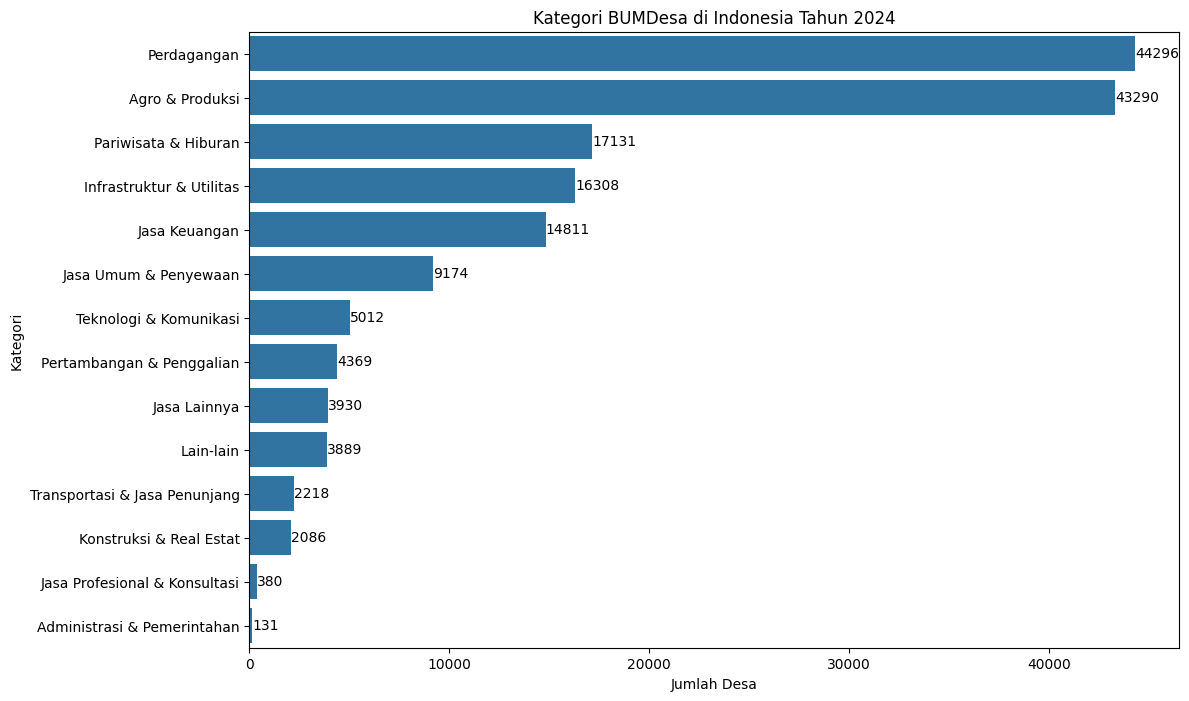

In [16]:
plt.figure(figsize=(12,8))
ax = sns.barplot(x=df_17['Kategori BUMDes'].value_counts().values, y=df_17['Kategori BUMDes'].value_counts().index)
for p in ax.patches:
    width = p.get_width()
    # Tempatkan teks di atas bar
    ax.text(
        y=p.get_y() + p.get_height() / 2, 
        x=width + 3,                    
        s=f'{width:.0f}',               
        ha='left',
        va='center'                      
    )
plt.title("Kategori BUMDesa di Indonesia Tahun 2024")
plt.xlabel('Jumlah Desa')
plt.ylabel('Kategori')
plt.show()

In [17]:
# Agregat Nilai untuk Visualisasi Peta
kategori_dominan = df_17.groupby(['Provinsi', 'Kabupaten', 'Kecamatan'])['Kategori BUMDes'].agg(lambda x: x.mode()[0]).reset_index()
kategori_dominan.rename(columns={'Kategori_BUMDes': 'Kategori_Dominan'}, inplace=True)
jumlah_bumdes = df_17.groupby(['Provinsi', 'Kabupaten', 'Kecamatan']).size().reset_index(name='Jumlah_BUMDes')
df_bumdes = pd.merge(kategori_dominan, jumlah_bumdes, on=['Provinsi', 'Kabupaten', 'Kecamatan'])

In [18]:
# Export file to excel for Tableau
file_excel = '17_bumdesa-kategori-usaha-processed.xlsx'
file_bumdes = 'bumdes_agregat.xlsx'
df_17.to_excel(file_excel, index=False)
df_bumdes.to_excel(file_bumdes, index=False)

![BUMDesa 2024](<images/Peta Jumlah BUMDesa 2024.png>)